In [1]:
import os, sys
os.chdir("..")
sys.path.insert(0, ".")


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
car_events = pd.read_csv('data/car_events.csv')
transfers  = pd.read_csv('data/transfers.csv')
compounds  = pd.read_csv('data/compounds.csv')

In [3]:
from src.preprocessing import flag_repair_cars, impute_repair_estimate, add_region_to_car_events

car_events = flag_repair_cars(car_events, transfers)
car_events = impute_repair_estimate(car_events, mode='median')
car_events = add_region_to_car_events(car_events, compounds)

## 1. Compound overview

In [4]:
from src.data_exploration import compound_role_map

compounds['cpd_type'] = compounds['compound_id'].map(compound_role_map())

car_events.pivot_table(
    values='event_id', aggfunc='count',
    index='compound_id', columns='event_type',
)

event_type,arrival_new_stock,arrival_return,arrival_transfer_in,departure_handover,departure_remarketing,departure_transfer_out
compound_id,,,,,,
CPD_BERLIN_01,2254,10094,13,10399,1558,191
CPD_BREMEN_01,431,2625,368,2933,232,200
CPD_COLOGNE_01,1511,7367,185,7629,1108,190
CPD_DRESDEN_01,337,2314,924,3106,150,260
CPD_DUSSELDORF_01,981,4795,16,4904,608,184
CPD_FRANKFURT_01,1861,8471,158,8695,1309,345
CPD_HAMBURG_01,2421,11098,362,11232,1754,738
CPD_LEIPZIG_01,379,2180,1037,2990,237,163
CPD_MUNICH_01,3520,15389,652,15849,2526,1008


In [5]:
from src.data_exploration import build_true_events

merged = build_true_events(car_events, transfers)

pivot = merged.pivot_table(
    values='event_id', aggfunc='count',
    index='compound_id', columns='true_event',
)
pivot.sort_values('departure_transfer_out_capacity_overflow', ascending=False)

true_event,arrival_new_stock,arrival_return,arrival_return_repair,arrival_transfer_in_capacity_overflow,arrival_transfer_in_demand_rebalancing,arrival_transfer_in_remarketing_routing,arrival_transfer_in_repair_routing,departure_handover,departure_remarketing,departure_transfer_out_capacity_overflow,departure_transfer_out_demand_rebalancing,departure_transfer_out_remarketing_routing,departure_transfer_out_repair_routing
compound_id,,,,,,,,,,,,,
CPD_MUNICH_01,3520.0,11590.0,3799.0,NaN,NaN,8.0,644.0,15849.0,2526.0,713.0,283.0,12.0,NaN
CPD_HAMBURG_01,2421.0,8407.0,2691.0,NaN,NaN,9.0,353.0,11232.0,1754.0,356.0,361.0,21.0,NaN
CPD_FRANKFURT_01,1861.0,6413.0,2058.0,NaN,NaN,8.0,150.0,8695.0,1309.0,134.0,191.0,20.0,NaN
CPD_COLOGNE_01,1511.0,5545.0,1822.0,NaN,NaN,16.0,169.0,7629.0,1108.0,56.0,127.0,7.0,NaN
CPD_STUTTGART_01,1188.0,4488.0,1420.0,NaN,NaN,23.0,NaN,6109.0,806.0,2.0,64.0,14.0,NaN
CPD_BERLIN_01,2254.0,7615.0,2479.0,NaN,NaN,13.0,NaN,10399.0,1558.0,NaN,NaN,18.0,173.0
CPD_BREMEN_01,431.0,1986.0,639.0,120.0,226.0,22.0,NaN,2933.0,232.0,NaN,NaN,20.0,180.0
CPD_DRESDEN_01,337.0,1715.0,599.0,524.0,390.0,10.0,NaN,3106.0,150.0,NaN,NaN,15.0,245.0
CPD_DUSSELDORF_01,981.0,3630.0,1165.0,NaN,NaN,16.0,NaN,4904.0,608.0,NaN,4.0,11.0,169.0


## 2. Monthly compound fullness

In [6]:
# Takes ~1-2 min (apply_repair_fifo runs once across full history).
# Run this cell before cells 24-26 — repair bottleneck analysis reuses ev.
from src.data_exploration import build_monthly_fullness
from src.simulation.stock import apply_repair_fifo

ev = apply_repair_fifo(car_events, compounds)

monthly_fullness = build_monthly_fullness(
    car_events, transfers, compounds,
    start_date='2024-01-01',
    end_date='2025-01-31',
)
monthly_fullness.head(20)

,month,compound_id,total_capacity,repair_capable,total,available,in_repair,waiting_repair,utilisation
0,2024-01,CPD_MUNICH_01,1200,True,1017,931,60,26,0.848
1,2024-01,CPD_MUNICH_02,350,False,17,13,0,4,0.049
2,2024-01,CPD_STUTTGART_01,500,True,357,330,27,0,0.714
3,2024-01,CPD_NUREMBERG_01,300,False,32,24,0,8,0.107
4,2024-01,CPD_COLOGNE_01,600,True,444,405,35,4,0.740
5,2024-01,CPD_DUSSELDORF_01,400,False,39,30,0,9,0.098
6,2024-01,CPD_FRANKFURT_01,700,True,536,500,36,0,0.766
7,2024-01,CPD_HAMBURG_01,900,True,761,707,45,9,0.846
8,2024-01,CPD_BREMEN_01,250,False,28,21,0,7,0.112
9,2024-01,CPD_BERLIN_01,800,False,97,73,0,24,0.121


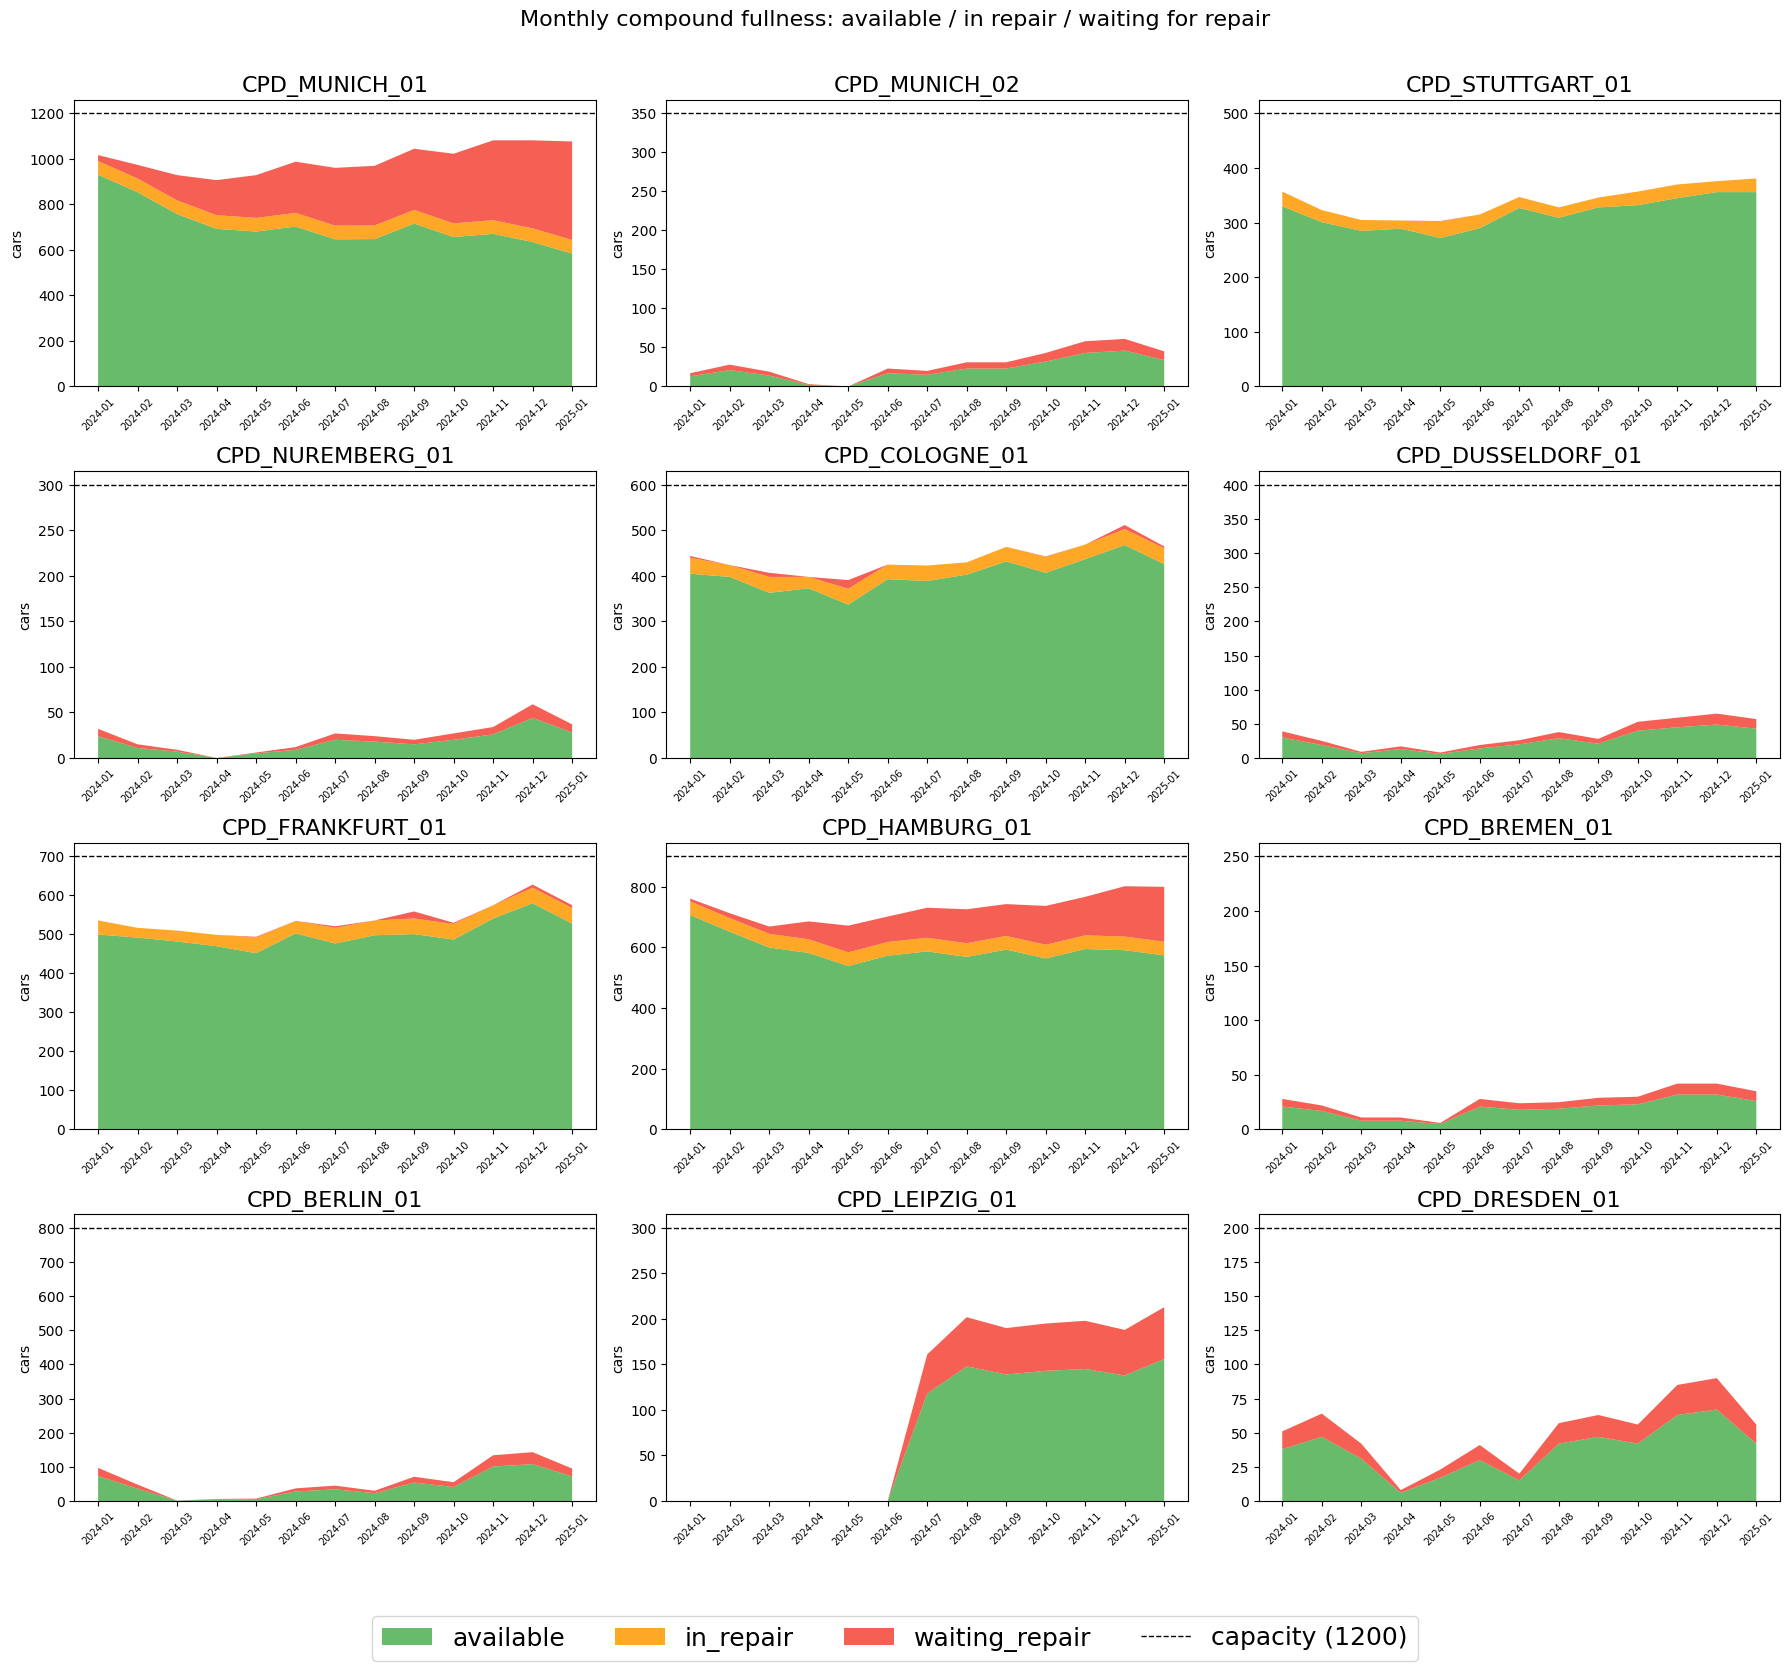

In [7]:
from src.data_exploration import plot_compound_fullness

plot_compound_fullness(monthly_fullness)

## 3. Transfer analysis by reason

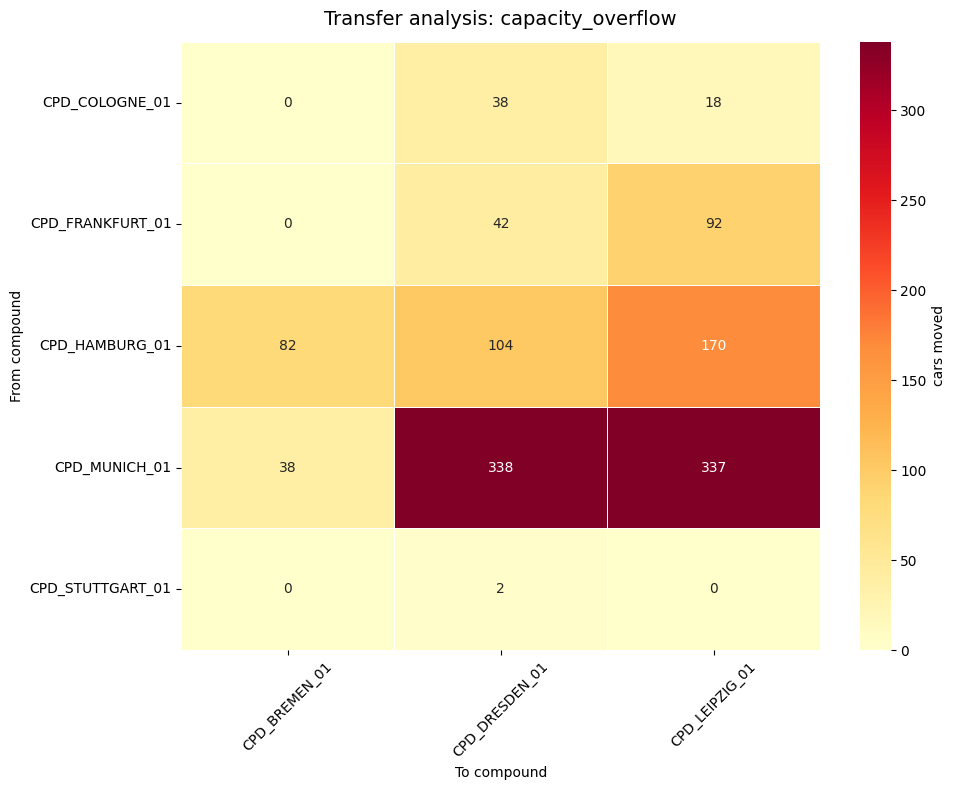

,from_compound_id,to_compound_id,cars,trucks,total_cost,avg_fill_pct,distance_km,cost_per_car
0,CPD_MUNICH_01,CPD_LEIPZIG_01,337,66,19995,78.1,469,59.3
1,CPD_MUNICH_01,CPD_DRESDEN_01,338,65,19620,78.6,467,58.0
2,CPD_HAMBURG_01,CPD_LEIPZIG_01,170,37,9396,76.7,382,55.3
3,CPD_HAMBURG_01,CPD_DRESDEN_01,104,21,6604,83.9,490,63.5
4,CPD_FRANKFURT_01,CPD_LEIPZIG_01,92,19,4847,71.0,382,52.7
5,CPD_MUNICH_01,CPD_BREMEN_01,38,7,3237,88.8,759,85.2
6,CPD_FRANKFURT_01,CPD_DRESDEN_01,42,10,3107,63.2,483,74.0
7,CPD_COLOGNE_01,CPD_DRESDEN_01,38,7,2691,71.7,617,70.8
8,CPD_COLOGNE_01,CPD_LEIPZIG_01,18,6,1900,43.0,494,105.6
9,CPD_HAMBURG_01,CPD_BREMEN_01,82,13,1427,87.0,123,17.4


In [8]:
from src.data_exploration import plot_transfer_analysis

plot_transfer_analysis(transfers, 'capacity_overflow')

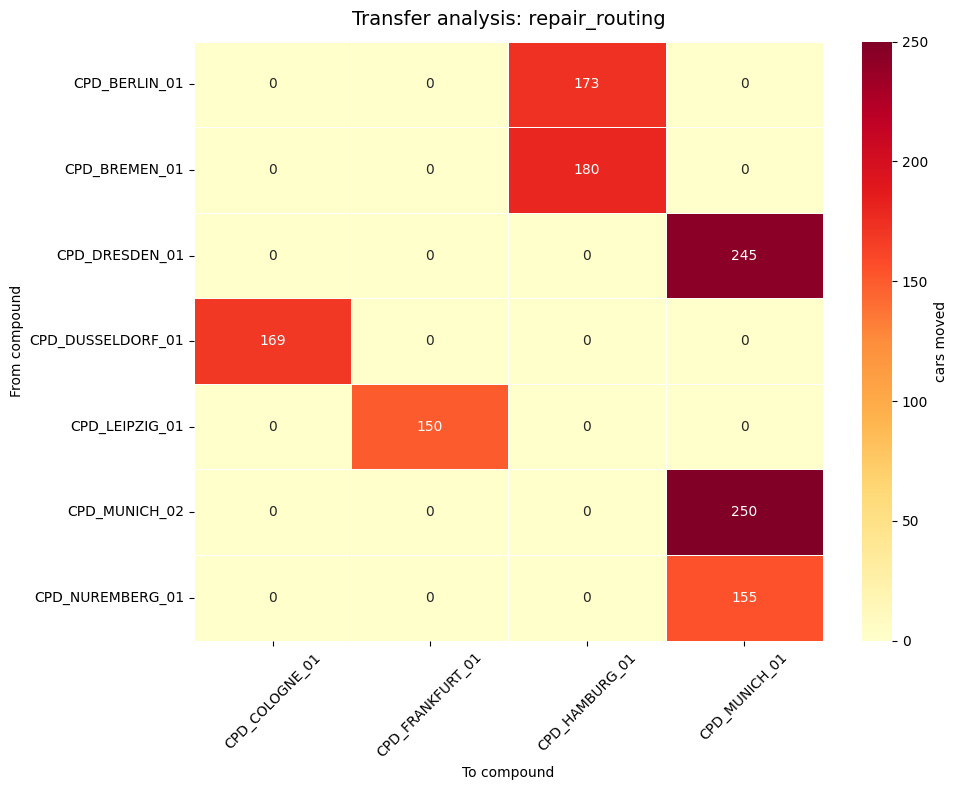

,from_compound_id,to_compound_id,cars,trucks,total_cost,avg_fill_pct,distance_km,cost_per_car
0,CPD_DRESDEN_01,CPD_MUNICH_01,245,71,21431,50.1,467,87.5
1,CPD_LEIPZIG_01,CPD_FRANKFURT_01,150,52,13265,45.5,382,88.4
2,CPD_BERLIN_01,CPD_HAMBURG_01,173,55,12480,47.0,332,72.1
3,CPD_NUREMBERG_01,CPD_MUNICH_01,155,62,9448,42.1,196,61.0
4,CPD_BREMEN_01,CPD_HAMBURG_01,180,60,6759,45.0,123,37.5
5,CPD_MUNICH_02,CPD_MUNICH_01,250,78,3853,47.2,8,15.4
6,CPD_DUSSELDORF_01,CPD_COLOGNE_01,169,55,3836,46.1,45,22.7


In [9]:
plot_transfer_analysis(transfers, 'repair_routing')

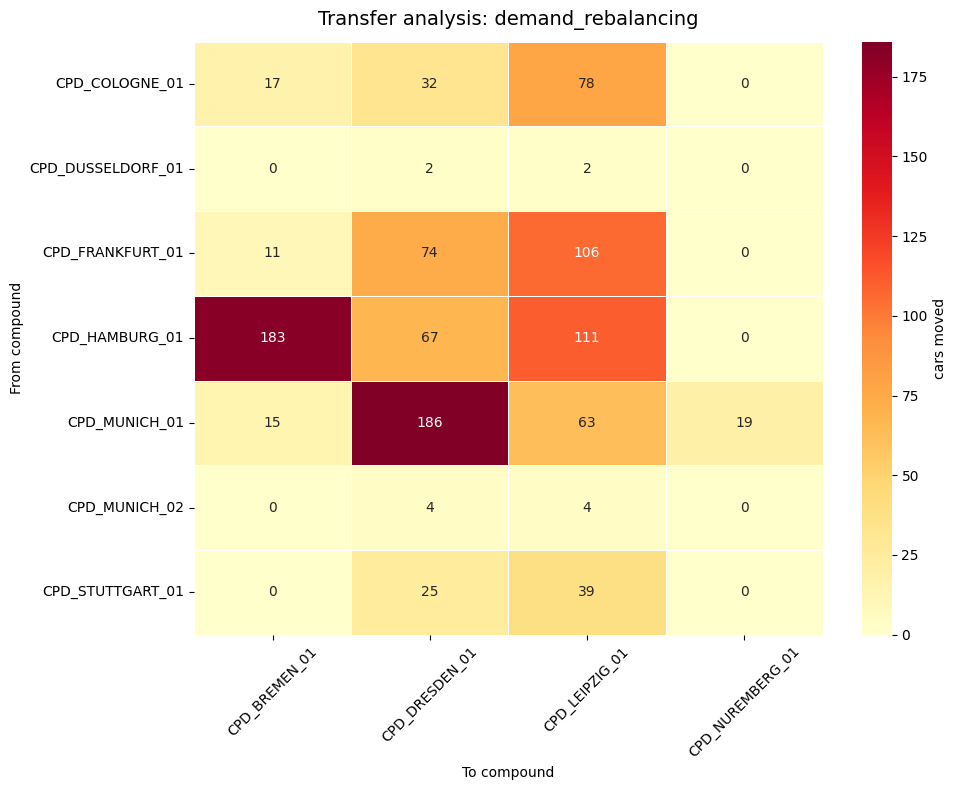

,from_compound_id,to_compound_id,cars,trucks,total_cost,avg_fill_pct,distance_km,cost_per_car
0,CPD_MUNICH_01,CPD_DRESDEN_01,186,41,12376,68.6,467,66.5
1,CPD_COLOGNE_01,CPD_LEIPZIG_01,78,30,9501,36.0,494,121.8
2,CPD_FRANKFURT_01,CPD_LEIPZIG_01,106,35,8929,41.5,382,84.2
3,CPD_FRANKFURT_01,CPD_DRESDEN_01,74,26,8077,38.7,483,109.1
4,CPD_HAMBURG_01,CPD_LEIPZIG_01,111,25,6341,65.8,382,57.1
5,CPD_HAMBURG_01,CPD_BREMEN_01,183,47,5295,56.9,123,28.9
6,CPD_HAMBURG_01,CPD_DRESDEN_01,67,16,5032,62.8,490,75.1
7,CPD_STUTTGART_01,CPD_LEIPZIG_01,39,15,4586,34.0,474,117.6
8,CPD_COLOGNE_01,CPD_DRESDEN_01,32,10,3844,45.2,617,120.1
9,CPD_STUTTGART_01,CPD_DRESDEN_01,25,11,3738,29.7,536,149.5


In [10]:
plot_transfer_analysis(transfers, 'demand_rebalancing')

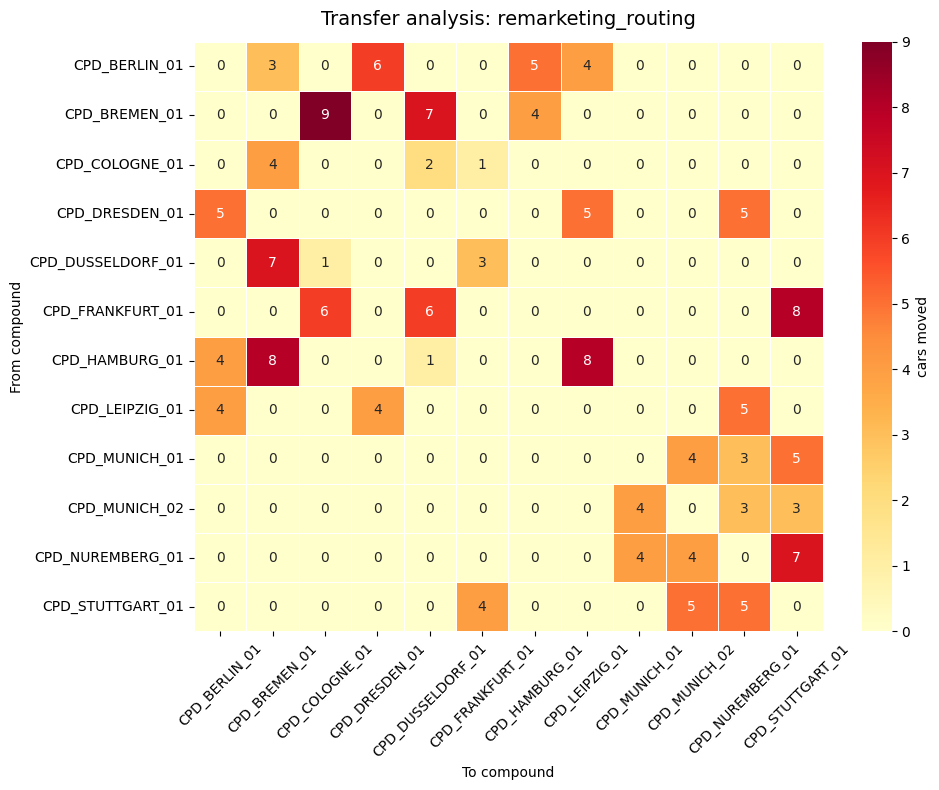

,from_compound_id,to_compound_id,cars,trucks,total_cost,avg_fill_pct,distance_km,cost_per_car
0,CPD_BREMEN_01,CPD_COLOGNE_01,9,9,2138,12.0,350,237.5
1,CPD_HAMBURG_01,CPD_LEIPZIG_01,8,8,1610,29.4,382,201.2
2,CPD_DUSSELDORF_01,CPD_BREMEN_01,7,7,1555,12.0,322,222.1
3,CPD_BREMEN_01,CPD_DUSSELDORF_01,7,7,1555,12.0,322,222.1
4,CPD_FRANKFURT_01,CPD_STUTTGART_01,8,8,1236,12.0,199,154.4
5,CPD_DRESDEN_01,CPD_NUREMBERG_01,5,5,1152,12.0,337,230.4
6,CPD_NUREMBERG_01,CPD_STUTTGART_01,7,7,1100,12.0,204,157.2
7,CPD_FRANKFURT_01,CPD_DUSSELDORF_01,6,6,1055,12.0,238,175.9
8,CPD_LEIPZIG_01,CPD_NUREMBERG_01,5,5,1044,12.0,298,208.9
9,CPD_BERLIN_01,CPD_DRESDEN_01,6,6,980,12.0,215,163.2


In [11]:
plot_transfer_analysis(transfers, 'remarketing_routing')

## 4. Repair capacity bottleneck

In [12]:
# Requires cell 8 to have been run (ev = apply_repair_fifo output).
from src.data_exploration import repair_queue_stats

wait = repair_queue_stats(ev, compounds)
print('=== How long does a car wait in queue before entering a repair bay? ===')
print(wait.to_string(index=False))

=== How long does a car wait in queue before entering a repair bay? ===
     compound_id  avg_wait  median_wait  max_wait  pct_over_2w
   CPD_MUNICH_01      79.6         78.0       150         91.3
  CPD_HAMBURG_01      41.9         41.0        82         83.7
  CPD_COLOGNE_01       1.7          1.0         9          0.0
CPD_FRANKFURT_01       1.7          0.0        10          0.0
CPD_STUTTGART_01       0.1          0.0         3          0.0


In [13]:
from src.data_exploration import repair_throughput_vs_inflow

tput = repair_throughput_vs_inflow(ev, compounds)
print('=== Repair inflow vs throughput (ratio > 1.0 = queue grows forever) ===')
print(tput.to_string(index=False))

=== Repair inflow vs throughput (ratio > 1.0 = queue grows forever) ===
     compound_id  bays  mean_repair_days  throughput_per_wk  inflow_per_wk  inflow/throughput
   CPD_MUNICH_01    60              11.9               35.3           42.3               1.20
  CPD_HAMBURG_01    45              11.9               26.4           29.0               1.10
  CPD_COLOGNE_01    35              12.2               20.1           19.0               0.94
CPD_FRANKFURT_01    40              12.0               23.4           21.0               0.90
CPD_STUTTGART_01    30              12.1               17.4           13.5               0.78


In [14]:
from src.data_exploration import repair_bay_utilisation

util = repair_bay_utilisation(monthly_fullness, compounds)
print('=== Repair bay utilisation by compound (avg and peak across all months) ===')
print(util.to_string(index=False))

=== Repair bay utilisation by compound (avg and peak across all months) ===
     compound_id  avg_bay_util_%  peak_bay_util_%
  CPD_HAMBURG_01           100.0            100.0
   CPD_MUNICH_01           100.0            100.0
  CPD_COLOGNE_01            91.9            100.0
CPD_FRANKFURT_01            88.8            100.0
CPD_STUTTGART_01            74.6            100.0
